=== Variables in MAT file ===
data21     | shape=(125, 34795, 20) | dtype=float64
fs         | shape=(1, 1) | dtype=uint8
subs21     | shape=(1, 20) | dtype=object

=== Core Info ===
data variable: data21
subs variable: subs21
data shape   : (125, 34795, 20)
fs           : 125.0
channels     : 125
time points  : 34795
subjects     : 20
duration (s) : 278.36
duration (m) : 4.64

=== Participants ===
['S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S19', 'S20', 'S21', 'S23']


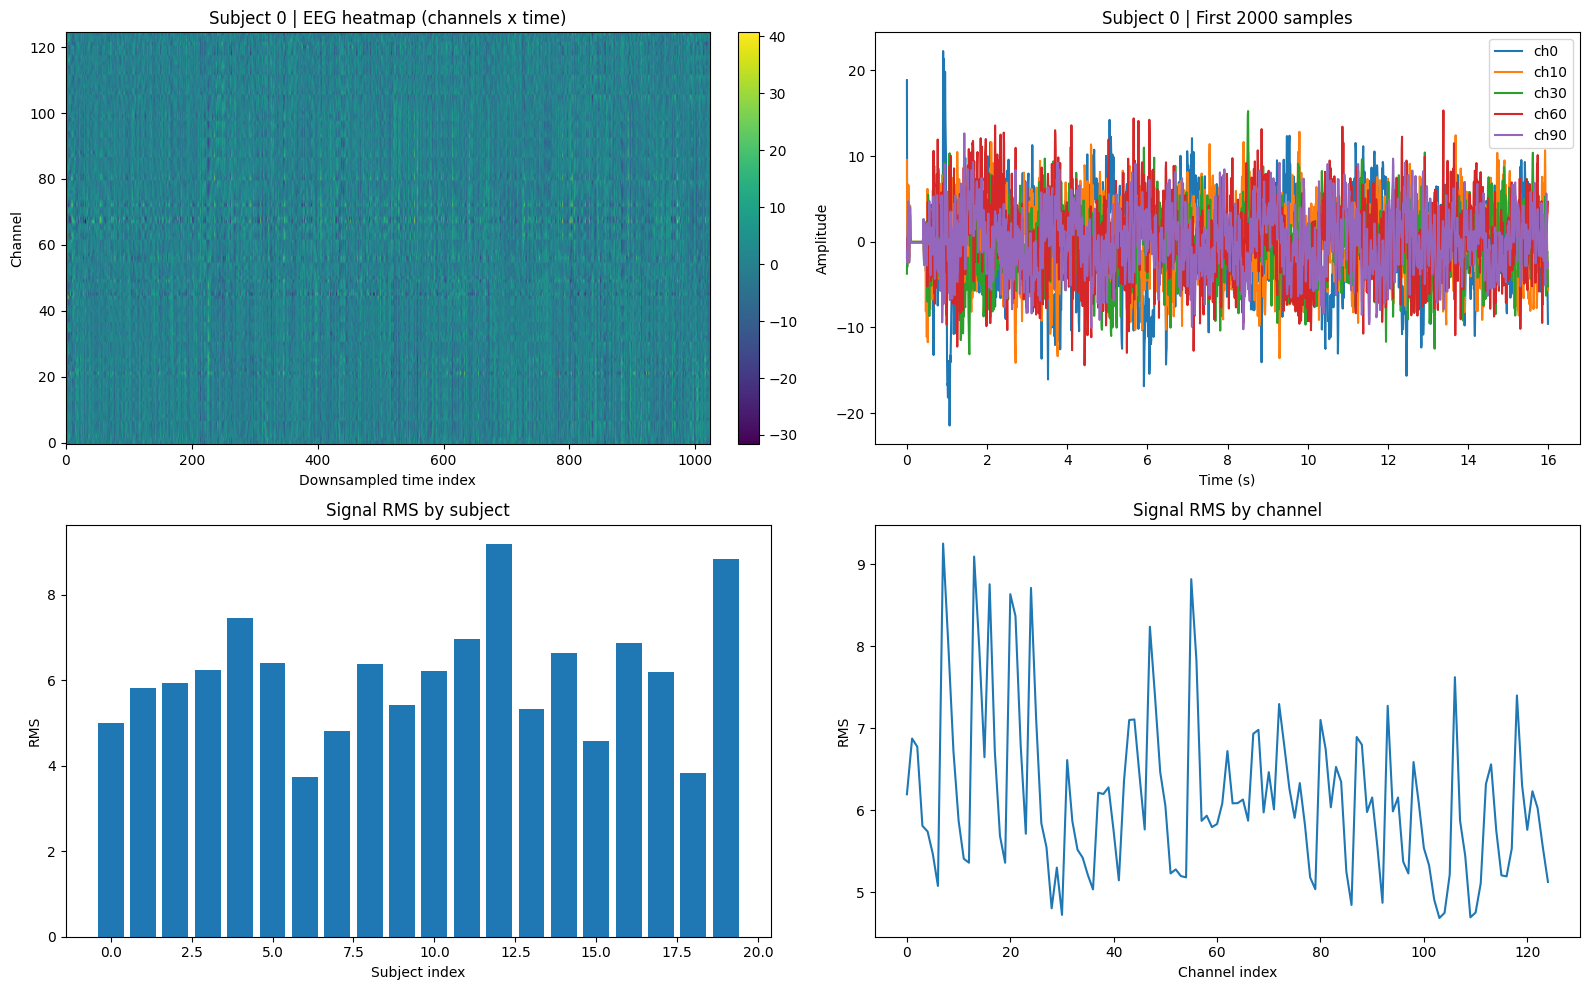

In [7]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# ===== 1. 指定你的 .mat 檔 =====
mat_path = "data/song21_Imputed.mat"   # 改成你的檔名

# ===== 2. 載入 .mat =====
mat = sio.loadmat(mat_path)

# ===== 3. 顯示所有變數 =====
print("=== Variables in MAT file ===")
for k, v in mat.items():
    if not k.startswith("__"):
        shape = getattr(v, "shape", None)
        dtype = getattr(v, "dtype", type(v))
        print(f"{k:10s} | shape={shape} | dtype={dtype}")

# ===== 4. 取主要變數 =====
# NMED-T 的命名通常是 dataSS / subsSS / fs
data_key = [k for k in mat.keys() if k.startswith("data")]
subs_key = [k for k in mat.keys() if k.startswith("subs")]

if len(data_key) == 0:
    raise ValueError("找不到 dataSS 類型的變數")
if len(subs_key) == 0:
    raise ValueError("找不到 subsSS 類型的變數")

data = mat[data_key[0]]
subs = mat[subs_key[0]]
fs = mat["fs"]

# fs 有時候是 2D array，要轉成純數字
fs = float(np.squeeze(fs))

print("\n=== Core Info ===")
print("data variable:", data_key[0])
print("subs variable:", subs_key[0])
print("data shape   :", data.shape)   # expected: (125, T, 20)
print("fs           :", fs)

n_channels, T, n_subjects = data.shape
duration_sec = T / fs

print(f"channels     : {n_channels}")
print(f"time points  : {T}")
print(f"subjects     : {n_subjects}")
print(f"duration (s) : {duration_sec:.2f}")
print(f"duration (m) : {duration_sec/60:.2f}")

# ===== 5. 整理 participant IDs =====
def flatten_subs(subs):
    out = []
    flat = np.ravel(subs)
    for x in flat:
        if isinstance(x, np.ndarray):
            if x.size == 1:
                out.append(str(x.item()))
            else:
                out.append(str(x))
        else:
            out.append(str(x))
    return out

subs_list = flatten_subs(subs)
print("\n=== Participants ===")
print(subs_list)

# ===== 6. 做 overview 圖 =====
fig = plt.figure(figsize=(16, 10))

# (A) Heatmap: subject 0 的所有 electrodes x time（下採樣顯示）
ax1 = plt.subplot(2, 2, 1)
subject_idx = 0
step = max(1, T // 1000)  # 避免太寬
img = data[:, ::step, subject_idx]
im = ax1.imshow(img, aspect='auto', origin='lower')
ax1.set_title(f"Subject {subject_idx} | EEG heatmap (channels x time)")
ax1.set_xlabel("Downsampled time index")
ax1.set_ylabel("Channel")
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

# (B) 幾個 channel 的時間波形
ax2 = plt.subplot(2, 2, 2)
time_axis = np.arange(T) / fs
channels_to_plot = [0, 10, 30, 60, 90]
for ch in channels_to_plot:
    if ch < n_channels:
        ax2.plot(time_axis[:2000], data[ch, :2000, subject_idx], label=f"ch{ch}")
ax2.set_title(f"Subject {subject_idx} | First 2000 samples")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.legend()

# (C) 每個受試者的整體訊號強度（RMS）
ax3 = plt.subplot(2, 2, 3)
subject_rms = np.sqrt(np.nanmean(data ** 2, axis=(0, 1)))
ax3.bar(np.arange(n_subjects), subject_rms)
ax3.set_title("Signal RMS by subject")
ax3.set_xlabel("Subject index")
ax3.set_ylabel("RMS")

# (D) 每個 electrode 的整體訊號強度
ax4 = plt.subplot(2, 2, 4)
channel_rms = np.sqrt(np.nanmean(data ** 2, axis=(1, 2)))
ax4.plot(channel_rms)
ax4.set_title("Signal RMS by channel")
ax4.set_xlabel("Channel index")
ax4.set_ylabel("RMS")

plt.tight_layout()
plt.show()